In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tadhgfitzgerald/fifa-international-soccer-mens-ranking-1993now/fifa_ranking.csv


Linhas: 57,793
Período: 1993-08-08 00:00:00 até 2018-06-07 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57793 entries, 0 to 57792
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   rank                     57793 non-null  int64         
 1   country_full             57793 non-null  object        
 2   country_abrv             57793 non-null  object        
 3   total_points             57793 non-null  float64       
 4   previous_points          57793 non-null  int64         
 5   rank_change              57793 non-null  int64         
 6   cur_year_avg             57793 non-null  float64       
 7   cur_year_avg_weighted    57793 non-null  float64       
 8   last_year_avg            57793 non-null  float64       
 9   last_year_avg_weighted   57793 non-null  float64       
 10  two_year_ago_avg         57793 non-null  float64       
 11  two_year_ago_weighted    

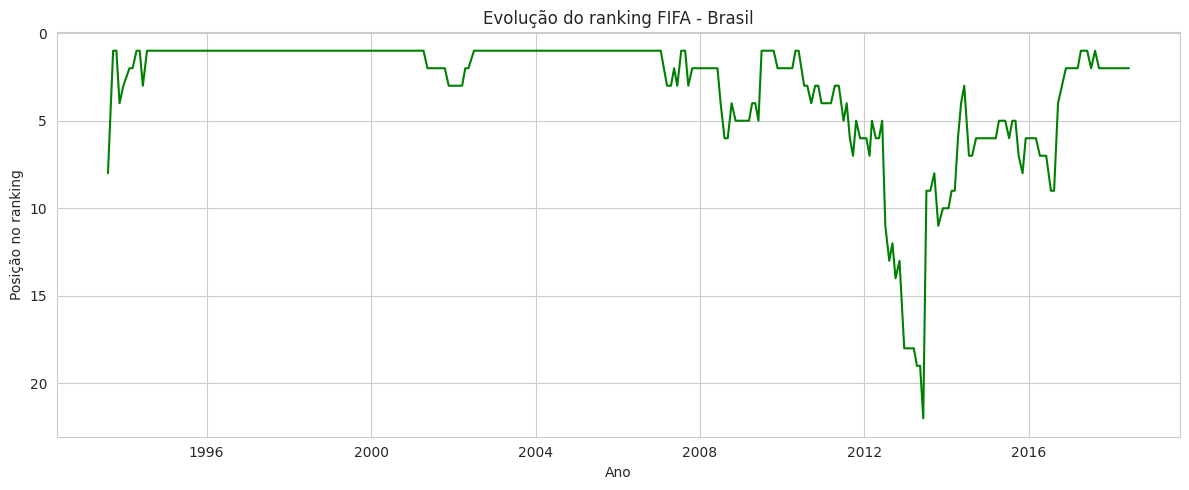

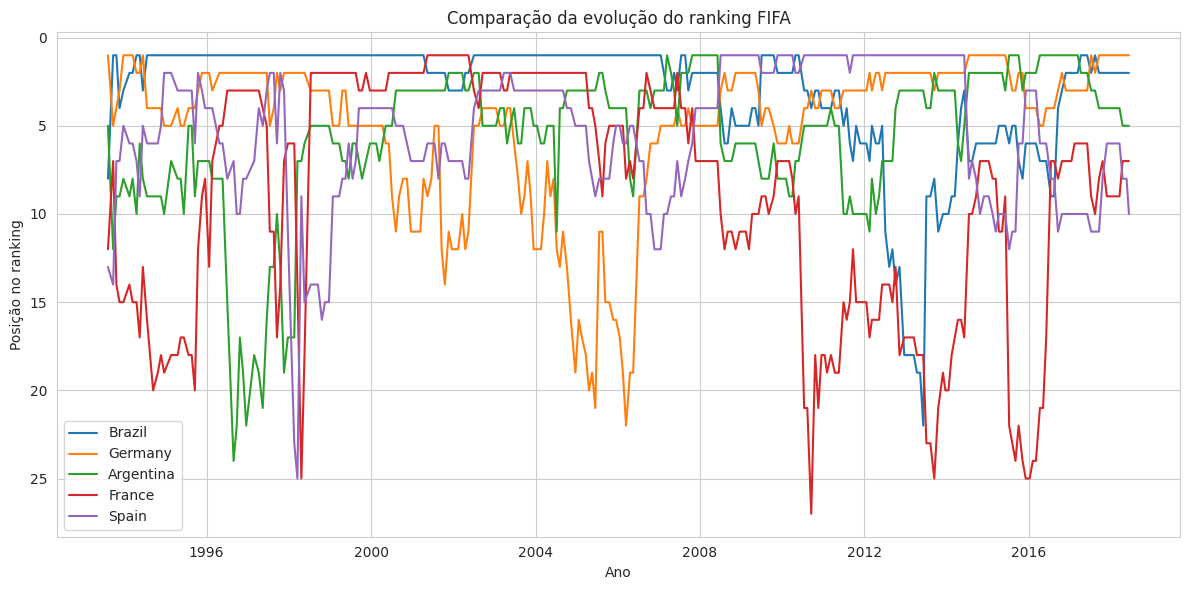

/tmp/ipykernel_16/682230003.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vezes_no_topo.head(10).values, y=vezes_no_topo.head(10).index, palette="rocket")


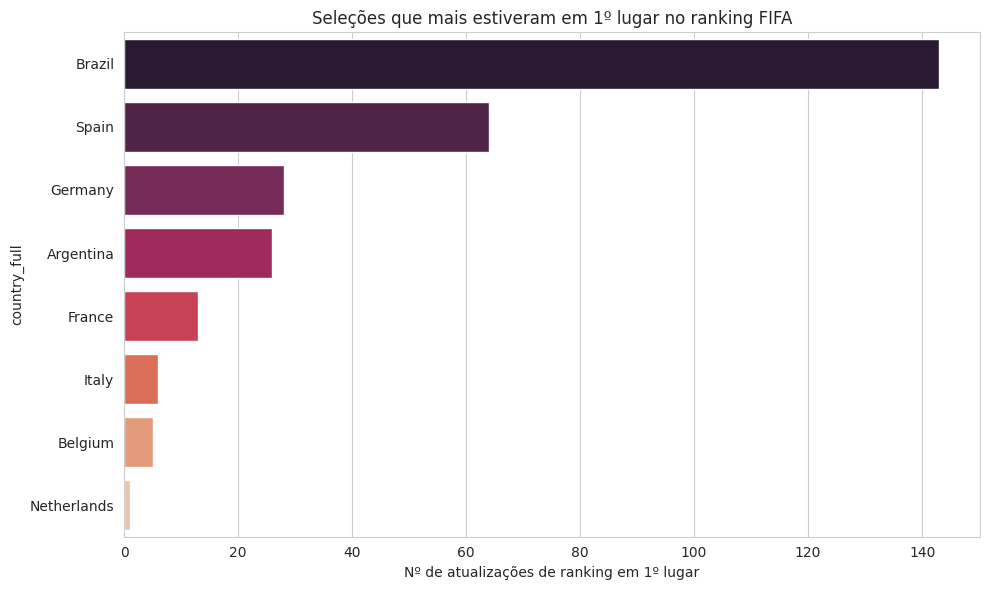

/tmp/ipykernel_16/682230003.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_confederacao.values, y=media_confederacao.index, palette="crest")


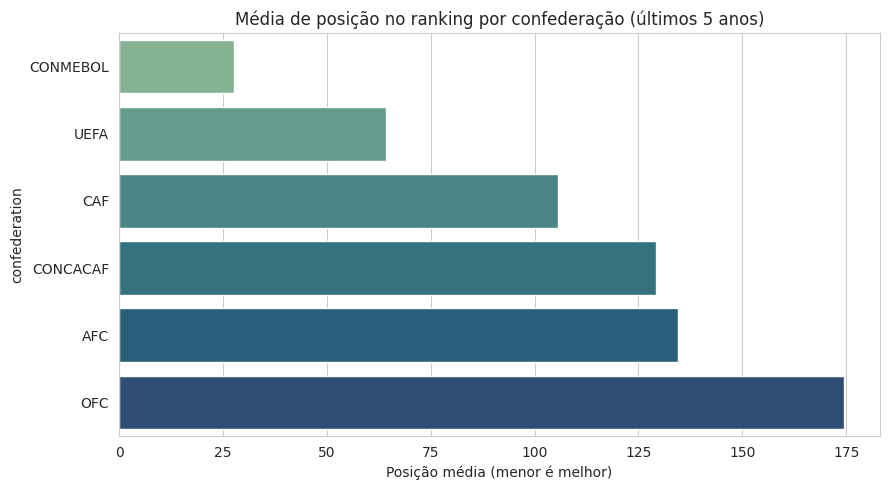

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ============================================
# 1. LEITURA
# ============================================

CAMINHO = "/kaggle/input/datasets/tadhgfitzgerald/fifa-international-soccer-mens-ranking-1993now/fifa_ranking.csv"

df = pd.read_csv(CAMINHO, parse_dates=["rank_date"])

print(f"Linhas: {len(df):,}")
print(f"Período: {df['rank_date'].min()} até {df['rank_date'].max()}")
print(df.info())

# ============================================
# 2. LIMPEZA
# ============================================

df["rank"] = df["rank"].astype(int)
df["total_points"] = df["total_points"].astype(float)
df["rank_change"] = df["rank_change"].astype(int)
df["ano"] = df["rank_date"].dt.year

# ============================================
# 3. ANÁLISE EXPLORATÓRIA
# ============================================

vezes_no_topo = df[df["rank"] == 1]["country_full"].value_counts()
print("\nSeleções que mais ficaram em 1º lugar (nº de atualizações de ranking):")
print(vezes_no_topo.head(10))

maior_pontuacao = df.loc[df["total_points"].idxmax()]
print(f"\nMaior pontuação histórica: {maior_pontuacao['country_full']} "
      f"com {maior_pontuacao['total_points']} pontos em {maior_pontuacao['rank_date'].date()}")

ultimo_ano = df["ano"].max()
recente = df[df["ano"] >= ultimo_ano - 5]
media_confederacao = recente.groupby("confederation")["rank"].mean().sort_values()
print("\nMédia de posição no ranking por confederação (últimos 5 anos):")
print(media_confederacao)

brasil = df[df["country_full"] == "Brazil"].sort_values("rank_date")
print(f"\nMelhor posição do Brasil: {brasil['rank'].min()}")
print(f"Pior posição do Brasil: {brasil['rank'].max()}")

# ============================================
# 4. VISUALIZAÇÕES
# ============================================

# Gráfico 1: Evolução do ranking do Brasil
plt.figure(figsize=(12, 5))
plt.plot(brasil["rank_date"], brasil["rank"], color="green")
plt.gca().invert_yaxis()
plt.title("Evolução do ranking FIFA - Brasil")
plt.xlabel("Ano")
plt.ylabel("Posição no ranking")
plt.tight_layout()
plt.savefig("evolucao_brasil.png", dpi=150)
plt.show()

# Gráfico 2: Comparação entre várias seleções
selecoes = ["Brazil", "Germany", "Argentina", "France", "Spain"]
plt.figure(figsize=(12, 6))
for pais in selecoes:
    dados_pais = df[df["country_full"] == pais].sort_values("rank_date")
    plt.plot(dados_pais["rank_date"], dados_pais["rank"], label=pais)

plt.gca().invert_yaxis()
plt.title("Comparação da evolução do ranking FIFA")
plt.xlabel("Ano")
plt.ylabel("Posição no ranking")
plt.legend()
plt.tight_layout()
plt.savefig("comparacao_selecoes.png", dpi=150)
plt.show()

# Gráfico 3: Top 10 seleções que mais ficaram em #1
plt.figure(figsize=(10, 6))
sns.barplot(x=vezes_no_topo.head(10).values, y=vezes_no_topo.head(10).index, palette="rocket")
plt.title("Seleções que mais estiveram em 1º lugar no ranking FIFA")
plt.xlabel("Nº de atualizações de ranking em 1º lugar")
plt.tight_layout()
plt.savefig("top10_primeiro_lugar.png", dpi=150)
plt.show()

# Gráfico 4: Média de posição por confederação
plt.figure(figsize=(9, 5))
sns.barplot(x=media_confederacao.values, y=media_confederacao.index, palette="crest")
plt.title("Média de posição no ranking por confederação (últimos 5 anos)")
plt.xlabel("Posição média (menor é melhor)")
plt.tight_layout()
plt.savefig("media_por_confederacao.png", dpi=150)
plt.show()